 # Training, Evaluation & Export

 **Task:** Periapical Lesion Detection — Model Training & Inference

 **Model:** Faster R-CNN + MobileNetV3-Large FPN



 ---

 ### Notebook Outline

 1. Environment Setup

 2. Google Drive Mounting & Path Configuration

 3. Dataset (Pascal VOC XML → PyTorch)

 4. Model Initialization & Training

 5. Evaluation on Test Set

 6. Visualization of Predictions

 7. Error Analysis

 8. Confusion Matrix

 9. Model Export

 10. Inference Utility Function

 ## 1. Environment Setup

In [ ]:
# ── Install dependencies ──────────────────────────────────────────────────────
!pip install torchvision pycocotools torchmetrics opencv-python-headless --quiet

import os, shutil, random, time, math, glob, json
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from pathlib import Path
from PIL import Image
from collections import defaultdict

import torch
import torchvision
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn
from torchvision.models.detection import FasterRCNN_MobileNet_V3_Large_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.auto import tqdm

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=' * 55)
print(f'PyTorch version  : {torch.__version__}')
print(f'Torchvision      : {torchvision.__version__}')
print(f'CUDA available   : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU              : {torch.cuda.get_device_name(0)}')
    print(f'VRAM             : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('  No GPU found - switch runtime to GPU (Runtime -> Change runtime type -> T4)')
print(f'Device           : {DEVICE}')
print('=' * 55)


PyTorch version  : 2.10.0+cu128
Torchvision      : 0.25.0+cu128
CUDA available   : True
GPU              : NVIDIA A100-SXM4-40GB
VRAM             : 42.4 GB
Device           : cuda


 ## 2. Google Drive Mounting & Path Configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# ── Paths ─────────────────────────────────────────────────────────────────────
WORK_DIR    = Path('/content/drive/MyDrive/Colab Notebooks')
DATASET_DIR = WORK_DIR / 'dataset2'

# Expected dataset structure:
#   dataset2/
#     train/
#       images/   <- image files (.jpg/.jpeg/.png)
#       labels/   <- XML annotation files (Pascal VOC format)
#     valid/
#       images/
#       labels/
#     test/
#       images/
#       labels/

SPLITS = ['train', 'valid', 'test']

# ── Class mapping (XML label name -> class index, 0 reserved for background) ──
CLASS_NAMES = ['__background__', 'Periapical_Type3', 'Periapical_Type4', 'Periapical_Type5']
XML_TO_IDX  = {'3': 1, '4': 2, '5': 3}   # XML label string -> class index
NUM_CLASSES = len(CLASS_NAMES)             # 4  (background + 3 classes)

print('Class Mapping:')
for xml_name, idx in XML_TO_IDX.items():
    print(f'  XML "{xml_name}" -> idx {idx} -> {CLASS_NAMES[idx]}')

# ── Verify dataset structure ──────────────────────────────────────────────────
print('\nChecking dataset structure:\n')
for split in SPLITS:
    split_dir  = DATASET_DIR / split
    images_dir = split_dir / 'images'
    labels_dir = split_dir / 'labels'

    images = []
    labels = []
    if images_dir.exists():
        images.extend(images_dir.glob('*.jpg'))
        images.extend(images_dir.glob('*.jpeg'))
        images.extend(images_dir.glob('*.png'))
    if labels_dir.exists():
        labels.extend(labels_dir.glob('*.xml'))

    img_stems = {p.stem for p in images}
    lbl_stems = {p.stem for p in labels}
    matched        = img_stems & lbl_stems
    missing_labels = img_stems - lbl_stems
    missing_images = lbl_stems - img_stems

    print(f'[{split.upper()}]')
    print(f'  images/ folder : {"OK" if images_dir.exists() else "MISSING"}')
    print(f'  labels/ folder : {"OK" if labels_dir.exists() else "MISSING"}')
    print(f'  Total images   : {len(images)}')
    print(f'  Total labels   : {len(labels)}')
    print(f'  Matched pairs  : {len(matched)}')
    if missing_labels:
        print(f'  Missing XMLs   : {len(missing_labels)}')
    if missing_images:
        print(f'  Missing imgs   : {len(missing_images)}')
    print('-' * 50)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Class Mapping:
  XML "3" -> idx 1 -> Periapical_Type3
  XML "4" -> idx 2 -> Periapical_Type4
  XML "5" -> idx 3 -> Periapical_Type5

Checking dataset structure:

[TRAIN]
  images/ folder : OK
  labels/ folder : OK
  Total images   : 2746
  Total labels   : 2746
  Matched pairs  : 2746
--------------------------------------------------
[VALID]
  images/ folder : OK
  labels/ folder : OK
  Total images   : 589
  Total labels   : 589
  Matched pairs  : 589
--------------------------------------------------
[TEST]
  images/ folder : OK
  labels/ folder : OK
  Total images   : 589
  Total labels   : 589
  Matched pairs  : 589
--------------------------------------------------


 ## 3. Dataset — Pascal VOC XML -> PyTorch



 ### Image Preprocessing: CLAHE Enhancement



 Dental X-rays are grayscale images with low local contrast. CLAHE (Contrast Limited

 Adaptive Histogram Equalization) enhances local contrast in small regions, making

 periapical lesions more distinguishable before feeding into the model. It is applied

 to the luminance channel of the image before converting to a 3-channel RGB tensor,

 preserving compatibility with the pretrained MobileNetV3 backbone.

In [ ]:
def parse_voc_xml(xml_path: Path, xml_to_idx: dict):
    """
    Parse a Pascal-VOC XML annotation file.

    Returns
    -------
    boxes  : list of [xmin, ymin, xmax, ymax] in absolute pixel coordinates
    labels : list of integer class indices
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes, labels = [], []

    for obj in root.findall('object'):
        name = obj.find('name').text.strip()
        if name not in xml_to_idx:
            continue   # skip unknown classes
        bnd  = obj.find('bndbox')
        xmin = float(bnd.find('xmin').text)
        ymin = float(bnd.find('ymin').text)
        xmax = float(bnd.find('xmax').text)
        ymax = float(bnd.find('ymax').text)
        # Guard: skip degenerate boxes
        if xmax <= xmin or ymax <= ymin:
            continue
        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(xml_to_idx[name])

    return boxes, labels


def apply_clahe(pil_image: Image.Image,
                clip_limit: float = 2.0,
                tile_grid_size: tuple = (8, 8)) -> Image.Image:
    """
    Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) to a PIL image.

    Dental X-rays are low-contrast grayscale images. CLAHE enhances local contrast
    within small tile regions, improving visibility of periapical lesions.

    Steps
    -----
    1. Convert RGB PIL image to grayscale numpy array.
    2. Apply OpenCV CLAHE on the grayscale channel.
    3. Stack the enhanced grayscale channel 3 times to produce a 3-channel RGB image.
       This preserves compatibility with the pretrained MobileNetV3 backbone which
       expects 3-channel input.

    Parameters
    ----------
    pil_image     : Input PIL Image (RGB).
    clip_limit    : Contrast clipping limit. Higher = more contrast enhancement.
    tile_grid_size: Tile size for local histogram equalization.

    Returns
    -------
    PIL Image (RGB) with CLAHE-enhanced contrast.
    """
    # Convert to grayscale numpy array for CLAHE
    img_np    = np.array(pil_image.convert('L'), dtype=np.uint8)

    # Create and apply CLAHE
    clahe     = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    enhanced  = clahe.apply(img_np)

    # Stack to 3 channels so pretrained backbone receives expected input shape
    enhanced_rgb = np.stack([enhanced, enhanced, enhanced], axis=2)

    return Image.fromarray(enhanced_rgb, mode='RGB')


class PeriapicalDataset(Dataset):
    """
    Dental X-ray dataset with CLAHE preprocessing.

    Expects the following directory structure:
        split_dir/
            images/   <- .jpg / .jpeg / .png
            labels/   <- .xml  (Pascal VOC format, same stem as image)

    CLAHE is applied to every image before the tensor transform pipeline.
    No data augmentation is used to keep training stable and fast.
    """

    def __init__(self, split_dir: Path, xml_to_idx: dict, transform=None):
        self.split_dir   = Path(split_dir)
        self.images_dir  = self.split_dir / 'images'
        self.labels_dir  = self.split_dir / 'labels'
        self.xml_to_idx  = xml_to_idx
        self.transform   = transform

        # Collect images that have a matching XML annotation file
        all_imgs = (sorted(self.images_dir.glob('*.jpg'))  +
                    sorted(self.images_dir.glob('*.jpeg')) +
                    sorted(self.images_dir.glob('*.png')))
        self.samples = []
        for img_p in all_imgs:
            xml_p = self.labels_dir / (img_p.stem + '.xml')
            if xml_p.exists():
                self.samples.append((img_p, xml_p))
            else:
                print(f'  [warn] No XML for {img_p.name} - skipped')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, xml_path = self.samples[idx]

        # ── Load and preprocess image ─────────────────────────────────────────
        img_pil = Image.open(img_path).convert('RGB')

        # Apply CLAHE for dental X-ray contrast enhancement
        img_pil = apply_clahe(img_pil)

        # ── Load annotations ──────────────────────────────────────────────────
        boxes, labels = parse_voc_xml(xml_path, self.xml_to_idx)

        if len(boxes) == 0:
            # Image with no valid annotations -> empty target
            boxes_t  = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,),   dtype=torch.int64)
            area_t   = torch.zeros((0,),   dtype=torch.float32)
            iscrowd  = torch.zeros((0,),   dtype=torch.int64)
        else:
            boxes_t  = torch.tensor(boxes,  dtype=torch.float32)
            labels_t = torch.tensor(labels, dtype=torch.int64)
            area_t   = ((boxes_t[:, 2] - boxes_t[:, 0]) *
                        (boxes_t[:, 3] - boxes_t[:, 1]))
            iscrowd  = torch.zeros((len(boxes),), dtype=torch.int64)

        target = {
            'boxes'    : boxes_t,
            'labels'   : labels_t,
            'image_id' : torch.tensor([idx]),
            'area'     : area_t,
            'iscrowd'  : iscrowd,
        }

        if self.transform:
            img_pil = self.transform(img_pil)

        return img_pil, target


def get_transform():
    """
    Minimal image transform pipeline with no augmentation.

    Only applies:
    1. ToTensor()   : Convert PIL image to float tensor in [0, 1].
    2. Normalize()  : ImageNet mean/std normalization required by pretrained backbone.

    Augmentation is intentionally excluded to keep training stable and fast on T4 GPU.
    """
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std =[0.229, 0.224, 0.225]),
    ])


def collate_fn(batch):
    return tuple(zip(*batch))


# ── Build datasets and data loaders ──────────────────────────────────────────
# num_workers=4, pin_memory=True, and persistent_workers=True are set for
# maximum DataLoader throughput on Colab T4 GPU runtime.

transform = get_transform()

train_dataset = PeriapicalDataset(DATASET_DIR / 'train', XML_TO_IDX, transform=transform)
valid_dataset = PeriapicalDataset(DATASET_DIR / 'valid', XML_TO_IDX, transform=transform)
test_dataset  = PeriapicalDataset(DATASET_DIR / 'test',  XML_TO_IDX, transform=transform)

train_loader = DataLoader(
    train_dataset, batch_size=4, shuffle=True,
    num_workers=4, pin_memory=True, persistent_workers=True,
    collate_fn=collate_fn
)
valid_loader = DataLoader(
    valid_dataset, batch_size=4, shuffle=False,
    num_workers=4, pin_memory=True, persistent_workers=True,
    collate_fn=collate_fn
)
test_loader = DataLoader(
    test_dataset, batch_size=4, shuffle=False,
    num_workers=4, pin_memory=True, persistent_workers=True,
    collate_fn=collate_fn
)

print(f'Train samples : {len(train_dataset)}')
print(f'Valid samples : {len(valid_dataset)}')
print(f'Test  samples : {len(test_dataset)}')

# ── Quick sanity check ────────────────────────────────────────────────────────
img_t, tgt = train_dataset[0]
print(f'\nSanity check - first sample:')
print(f'  Image tensor shape : {img_t.shape}')
print(f'  Boxes              : {tgt["boxes"]}')
print(f'  Labels             : {tgt["labels"]}')


Train samples : 2746
Valid samples : 589
Test  samples : 589


/tmp/ipykernel_1380/748942199.py:69: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(enhanced_rgb, mode='RGB')



Sanity check - first sample:
  Image tensor shape : torch.Size([3, 1252, 2473])
  Boxes              : tensor([[1694.,  848., 1735.,  890.]])
  Labels             : tensor([1])


 ## 4. Model Initialization & Training



 ### Architecture: Faster R-CNN + MobileNetV3-Large FPN



 - **Two-stage detector**: Region Proposal Network (RPN) + classification head

   delivers high accuracy on small periapical lesions.

 - **MobileNetV3-Large backbone**: Significantly lighter and faster than ResNet-101

   (~3-4x faster training on T4), enabling a full 30-epoch run within 2.5-3 hours.

 - **FPN (Feature Pyramid Network)**: Multi-scale features allow detection of

   lesions at different sizes.

 - **COCO pretrained weights**: Transfer learning for rapid convergence.



 ### Small Object Detection: Custom Anchor Generator



 Periapical lesions are very small relative to the full X-ray image. The default

 Faster R-CNN anchor sizes are too large for reliable small lesion detection.

 A custom AnchorGenerator with smaller anchor sizes is used:

   (16,), (32,), (64,), (128,), (256,)

 This allows the RPN to propose regions at the scale of actual lesions.



 ### Backbone Freezing



 trainable_backbone_layers=1 freezes most of the backbone (only the last layer

 group remains trainable). This reduces training cost, stabilizes transfer

 learning, and keeps total training time within the T4 budget.



 ### Mixed Precision Training (AMP)



 torch.cuda.amp.autocast and GradScaler are used to run forward passes in

 float16 where possible. This roughly doubles throughput on T4 GPU and reduces

 VRAM usage, allowing a larger effective batch size.

In [ ]:
def build_faster_rcnn(num_classes: int, trainable_backbone_layers: int = 1):
    """
    Build Faster R-CNN with MobileNetV3-Large FPN backbone and a custom
    small-object anchor generator.

    Parameters
    ----------
    num_classes              : Total classes including background (e.g., 4).
    trainable_backbone_layers: Number of backbone layer groups to unfreeze.
                               Lower = faster training, more frozen weights.
                               Set to 1 for T4 efficiency with stable transfer learning.

    Anchor sizes are tuned for small periapical lesions:
        (16,), (32,), (64,), (128,), (256,)
    Standard default sizes (32, 64, 128, 256, 512) are too large for tiny lesions.
    """
    # # Custom anchor generator sized for small dental lesions
    # # Each tuple corresponds to one FPN level feature map
    # anchor_generator = AnchorGenerator(
    #     sizes=((16,), (32,), (64,), (128,), (256,)),
    #     aspect_ratios=((0.5, 1.0, 2.0),) * 5,
    # )

    # Load pretrained MobileNetV3-Large FPN model with COCO weights
    model = fasterrcnn_mobilenet_v3_large_fpn(
        weights                   = FasterRCNN_MobileNet_V3_Large_FPN_Weights.COCO_V1,
        trainable_backbone_layers = trainable_backbone_layers,
        min_size                  = 800,    # resize shorter side to 800px for lesion resolution
        max_size                  = 1333,
        # rpn_anchor_generator      = anchor_generator,
    )

    # Replace the classification head with one matching our number of classes
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


model = build_faster_rcnn(NUM_CLASSES, trainable_backbone_layers=1)
model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Backbone             : MobileNetV3-Large FPN')
print(f'min_size             : 800')
print(f'Anchor sizes         : (16,) (32,) (64,) (128,) (256,)')
print(f'Trainable layers     : 1 (most backbone frozen for T4 efficiency)')
print(f'Total parameters     : {total_params / 1e6:.1f} M')
print(f'Trainable parameters : {train_params / 1e6:.1f} M')


Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


100%|██████████| 74.2M/74.2M [00:00<00:00, 183MB/s]


Backbone             : MobileNetV3-Large FPN
min_size             : 800
Anchor sizes         : (16,) (32,) (64,) (128,) (256,)
Trainable layers     : 1 (most backbone frozen for T4 efficiency)
Total parameters     : 18.9 M
Trainable parameters : 16.1 M


In [ ]:
# ── Training configuration ────────────────────────────────────────────────────
NUM_EPOCHS   = 50
LR           = 0.001
WEIGHT_DECAY = 0.0005
CONF_THR     = 0.01        # confidence threshold for inference and evaluation
IOU_THR      = 0.5         # IoU threshold for TP matching

RUN_DIR = WORK_DIR / 'runs' / 'periapical_frcnn_mobilenetv3'
RUN_DIR.mkdir(parents=True, exist_ok=True)
BEST_PT = RUN_DIR / 'best.pt'

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR, weight_decay=WEIGHT_DECAY
)

# Cosine annealing gradually reduces LR to near-zero over training
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

# AMP GradScaler for mixed precision training on T4 GPU
scaler = GradScaler()

print(f'NUM_EPOCHS   : {NUM_EPOCHS}')
print(f'LR           : {LR}')
print(f'WEIGHT_DECAY : {WEIGHT_DECAY}')
print(f'CONF_THR     : {CONF_THR}')
print(f'IOU_THR      : {IOU_THR}')
print(f'AMP          : enabled (GradScaler + autocast)')
print(f'Run dir      : {RUN_DIR}')


NUM_EPOCHS   : 50
LR           : 0.001
WEIGHT_DECAY : 0.0005
CONF_THR     : 0.01
IOU_THR      : 0.5
AMP          : enabled (GradScaler + autocast)
Run dir      : /content/drive/MyDrive/Colab Notebooks/runs/periapical_frcnn_mobilenetv3


/tmp/ipykernel_1380/3117341697.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


 ### Evaluation: Official mAP via torchmetrics



 The custom approximate mAP implementation is replaced with the official

 `torchmetrics.detection.MeanAveragePrecision` metric. This computes:



 - **mAP@0.5**      : Standard COCO-style AP at IoU=0.5

 - **mAP@0.5:0.95** : COCO primary metric (average over IoU thresholds 0.5 to 0.95)

 - **Per-class AP** : Individual AP for each lesion type

 - **Precision / Recall**: Global detection quality metrics



 Predictions are accumulated across the full validation set and evaluated in a

 single batched pass, which is significantly faster than per-image evaluation loops.

In [ ]:
from pathlib import Path
from PIL import Image
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict

def inspect_xml_split(split_dir, xml_to_idx):
    split_dir = Path(split_dir)
    images_dir = split_dir / 'images'
    labels_dir = split_dir / 'labels'

    image_map = {}
    for p in list(images_dir.glob('*.jpg')) + list(images_dir.glob('*.jpeg')) + list(images_dir.glob('*.png')):
        image_map[p.stem] = p

    raw_name_counter = Counter()
    unknown_names = Counter()
    total_xml = 0
    total_objects = 0
    valid_objects = 0
    degenerate_boxes = 0
    out_of_bounds_boxes = 0
    empty_after_parse = 0
    missing_image = 0
    width_stats = []
    height_stats = []
    bad_examples = []

    for xml_path in sorted(labels_dir.glob('*.xml')):
        total_xml += 1
        stem = xml_path.stem

        if stem not in image_map:
            missing_image += 1
            bad_examples.append(f"[MISSING IMAGE] {xml_path.name}")
            continue

        img_path = image_map[stem]
        w, h = Image.open(img_path).size

        tree = ET.parse(xml_path)
        root = tree.getroot()

        this_valid = 0

        for obj in root.findall('object'):
            total_objects += 1
            name = obj.find('name').text.strip()
            raw_name_counter[name] += 1

            if name not in xml_to_idx:
                unknown_names[name] += 1
                continue

            bnd = obj.find('bndbox')
            xmin = float(bnd.find('xmin').text)
            ymin = float(bnd.find('ymin').text)
            xmax = float(bnd.find('xmax').text)
            ymax = float(bnd.find('ymax').text)

            if xmax <= xmin or ymax <= ymin:
                degenerate_boxes += 1
                bad_examples.append(
                    f"[DEGENERATE] {xml_path.name} -> ({xmin}, {ymin}, {xmax}, {ymax})"
                )
                continue

            bw = xmax - xmin
            bh = ymax - ymin
            width_stats.append(bw)
            height_stats.append(bh)

            if xmin < 0 or ymin < 0 or xmax > w or ymax > h:
                out_of_bounds_boxes += 1
                bad_examples.append(
                    f"[OUT OF BOUNDS] {xml_path.name} img=({w},{h}) box=({xmin},{ymin},{xmax},{ymax})"
                )

            valid_objects += 1
            this_valid += 1

        if this_valid == 0:
            empty_after_parse += 1

    print("=" * 70)
    print(f"SPLIT: {split_dir.name}")
    print("=" * 70)
    print(f"Total XML files              : {total_xml}")
    print(f"Missing matching images      : {missing_image}")
    print(f"Total objects in XML         : {total_objects}")
    print(f"Valid objects after parsing  : {valid_objects}")
    print(f"Images empty after parsing   : {empty_after_parse}")
    print(f"Degenerate boxes             : {degenerate_boxes}")
    print(f"Out-of-bounds boxes          : {out_of_bounds_boxes}")
    print()

    print("Raw class names found:")
    for k, v in raw_name_counter.most_common():
        print(f"  {repr(k):>12} : {v}")

    print()
    print("Unknown class names (not in XML_TO_IDX):")
    if len(unknown_names) == 0:
        print("  None ✅")
    else:
        for k, v in unknown_names.most_common():
            print(f"  {repr(k):>12} : {v}")

    print()
    if len(width_stats) > 0:
        print("Box size stats:")
        print(f"  Width  min/mean/max : {min(width_stats):.2f} / {sum(width_stats)/len(width_stats):.2f} / {max(width_stats):.2f}")
        print(f"  Height min/mean/max : {min(height_stats):.2f} / {sum(height_stats)/len(height_stats):.2f} / {max(height_stats):.2f}")
    else:
        print("No valid boxes found ❌")

    print()
    print("Sample bad examples:")
    if len(bad_examples) == 0:
        print("  None ✅")
    else:
        for x in bad_examples[:15]:
            print(" ", x)

for split in ["train", "valid", "test"]:
    inspect_xml_split(DATASET_DIR / split, XML_TO_IDX)
    print("\n")

SPLIT: train
Total XML files              : 2746
Missing matching images      : 0
Total objects in XML         : 4671
Valid objects after parsing  : 4671
Images empty after parsing   : 0
Degenerate boxes             : 0
Out-of-bounds boxes          : 0

Raw class names found:
           '3' : 2962
           '4' : 1218
           '5' : 491

Unknown class names (not in XML_TO_IDX):
  None ✅

Box size stats:
  Width  min/mean/max : 27.00 / 67.92 / 446.00
  Height min/mean/max : 25.00 / 67.36 / 262.00

Sample bad examples:
  None ✅


SPLIT: valid
Total XML files              : 589
Missing matching images      : 0
Total objects in XML         : 1033
Valid objects after parsing  : 1033
Images empty after parsing   : 0
Degenerate boxes             : 0
Out-of-bounds boxes          : 0

Raw class names found:
           '3' : 650
           '4' : 275
           '5' : 108

Unknown class names (not in XML_TO_IDX):
  None ✅

Box size stats:
  Width  min/mean/max : 26.00 / 68.22 / 467.00
  Height 

/tmp/ipykernel_1380/748942199.py:69: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(enhanced_rgb, mode='RGB')


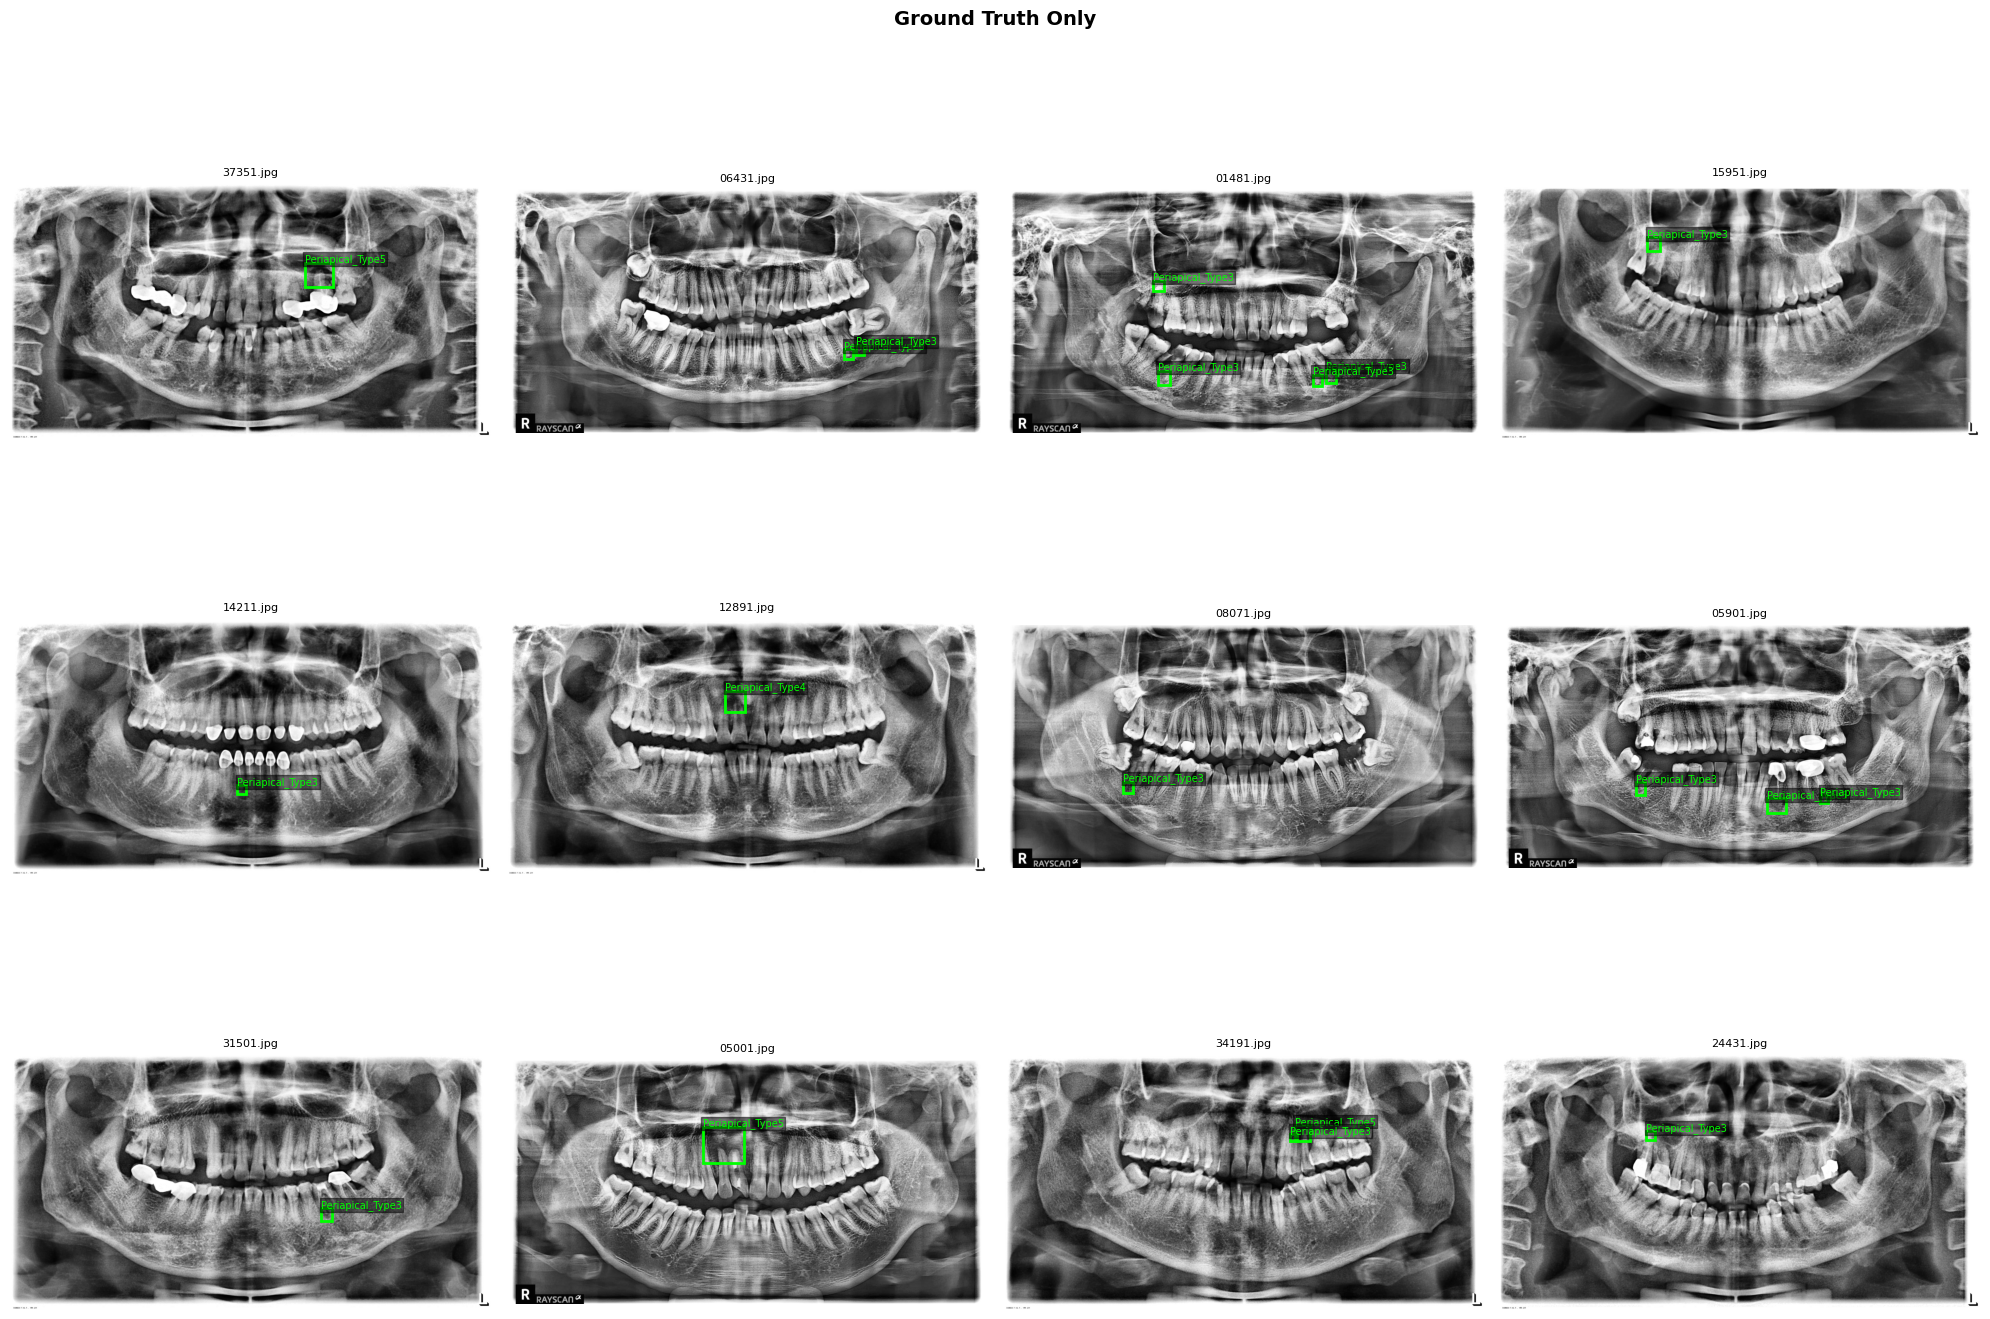

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def denormalize_for_display(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)

def show_gt_samples(dataset, class_names, n=12, seed=42):
    random.seed(seed)
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    cols = 4
    rows = (len(indices) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
    axes = np.array(axes).reshape(-1)

    for ax, idx in zip(axes, indices):
        img_t, tgt = dataset[idx]
        img_np = denormalize_for_display(img_t).permute(1, 2, 0).numpy()
        ax.imshow(img_np)
        ax.set_title(dataset.samples[idx][0].name, fontsize=8)
        ax.axis("off")

        boxes = tgt["boxes"].numpy()
        labels = tgt["labels"].numpy()

        for box, cls_id in zip(boxes, labels):
            x1, y1, x2, y2 = box
            rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                      linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, max(2, y1 - 4), class_names[cls_id],
                    color='lime', fontsize=7,
                    bbox=dict(facecolor='black', alpha=0.5, pad=1))

    for ax in axes[len(indices):]:
        ax.axis("off")

    plt.suptitle("Ground Truth Only", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_gt_samples(train_dataset, CLASS_NAMES, n=12)

In [ ]:
@torch.no_grad()
def evaluate_map(model, loader, conf_thr=0.01, desc='Val'):
    """
    Compute official mAP@0.5 and mAP@0.5:0.95 using torchmetrics.

    Parameters
    ----------
    model    : Faster R-CNN model in eval mode.
    loader   : DataLoader for the evaluation split.
    conf_thr : Confidence threshold; predictions below this are discarded.
    desc     : Label for the tqdm progress bar.

    Returns
    -------
    dict with keys: map50, map, precision, recall, per_class_ap
    """
    model.eval()

    # torchmetrics MeanAveragePrecision accumulates predictions across batches
    metric = MeanAveragePrecision(iou_type='bbox', class_metrics=True)
    metric.to(DEVICE)

    pbar = tqdm(loader, desc=f'  {desc}', leave=False, ncols=80)
    for images, targets in pbar:
        images = [img.to(DEVICE) for img in images]

        outputs = model(images)

        # Format predictions for torchmetrics
        preds_tm = []
        for out in outputs:
            keep = out['scores'] >= conf_thr
            preds_tm.append({
                'boxes' : out['boxes'][keep].cpu(),
                'scores': out['scores'][keep].cpu(),
                'labels': out['labels'][keep].cpu(),
            })

        # Format ground truth for torchmetrics
        targets_tm = []
        for tgt in targets:
            targets_tm.append({
                'boxes' : tgt['boxes'].cpu(),
                'labels': tgt['labels'].cpu(),
            })

        metric.update(preds_tm, targets_tm)

    results   = metric.compute()
    map50     = float(results['map_50'].item())
    map_all   = float(results['map'].item())
    precision = float(results.get('precision', torch.tensor(0.0)).mean().item())
    recall    = float(results.get('recall',    torch.tensor(0.0)).mean().item())

    # Per-class AP at IoU=0.5 (one value per foreground class)
    per_class_ap = []
    if 'map_per_class' in results:
        per_class_ap = results['map_per_class'].tolist()

    return {
        'map50'       : map50,
        'map'         : map_all,
        'precision'   : precision,
        'recall'      : recall,
        'per_class_ap': per_class_ap,
    }


 ### Training Loop



 Key design decisions for T4 GPU efficiency:



 - **AMP autocast**: Forward pass runs in float16 to maximize GPU throughput.

 - **GradScaler**: Prevents gradient underflow from float16 gradients.

 - **Gradient clipping**: max_norm=5.0 prevents exploding gradients.

 - **Validation every epoch**: Full mAP evaluation runs after every training epoch

   using the efficient torchmetrics pipeline.

 - **YOLO-style log format**: Compact per-epoch table with loss components,

   validation metrics, GPU memory, and epoch time.

In [ ]:
from IPython.display import clear_output

def gpu_mem_str():
    """Return current GPU memory usage as a formatted string (e.g., '4.5G')."""
    if not torch.cuda.is_available():
        return '0.0G'
    used = torch.cuda.memory_reserved(0) / 1e9
    return f'{used:.1f}G'


def live_plot(history, epoch, num_epochs, elapsed_sec, best_map50):
    """Clear output and redraw training curves after each epoch."""
    clear_output(wait=True)

    epochs_x   = history['epochs']
    train_loss = history['train_loss']
    val_map50  = history['val_map50']
    val_map    = history['val_map']

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(
        f'Faster R-CNN MobileNetV3  |  Epoch {epoch}/{num_epochs}  '
        f'|  Best mAP50={best_map50:.4f}  '
        f'|  Elapsed {int(elapsed_sec//3600):02d}h{int((elapsed_sec%3600)//60):02d}m',
        fontsize=11, fontweight='bold'
    )

    # Training loss
    axes[0].plot(epochs_x, train_loss, marker='o', color='steelblue', label='Train Loss')
    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.4)
    axes[0].legend()

    # mAP@0.5
    axes[1].plot(epochs_x, val_map50, marker='s', color='darkorange', label='Val mAP@0.5')
    if val_map50:
        best_idx = int(np.argmax(val_map50))
        axes[1].axvline(epochs_x[best_idx], color='green', linestyle='--',
                        alpha=0.6, label=f'Best={val_map50[best_idx]:.4f}')
    axes[1].set_title('Validation mAP@0.5')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('mAP50')
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(True, alpha=0.4)
    axes[1].legend()

    # mAP@0.5:0.95
    axes[2].plot(epochs_x, val_map, marker='^', color='purple', label='Val mAP@0.5:0.95')
    axes[2].set_title('Validation mAP@0.5:0.95')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('mAP')
    axes[2].set_ylim(0, 1.05)
    axes[2].grid(True, alpha=0.4)
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(str(RUN_DIR / 'training_curves.png'), dpi=120, bbox_inches='tight')
    plt.show()


# ── Training loop ─────────────────────────────────────────────────────────────
history = {
    'epochs'    : [],
    'train_loss': [],
    'val_map50' : [],
    'val_map'   : [],
}
best_map50 = 0.0
t_start    = time.time()

# Print YOLO-style header
header = (f"{'Epoch':>8}  {'GPU_mem':>8}  {'box_loss':>9}  {'cls_loss':>9}  "
          f"{'rpn_loss':>9}  {'Instances':>10}  {'Size':>6}")
sep = '-' * len(header)

print(sep)
print(header)
print(sep)

for epoch in range(1, NUM_EPOCHS + 1):

    # ── Train one epoch ───────────────────────────────────────────────────────
    model.train()
    epoch_loss   = 0.0
    loss_cls_sum = 0.0
    loss_box_sum = 0.0
    loss_rpn_sum = 0.0
    total_instances = 0

    pbar = tqdm(train_loader, desc=f'  Train {epoch}/{NUM_EPOCHS}',
                leave=False, ncols=80)
    for images, targets in pbar:
        images  = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        # Mixed precision forward pass
        with autocast():
            loss_dict = model(images, targets)
            losses    = sum(loss_dict.values())

        # Scaled backward pass
        scaler.scale(losses).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss   += losses.item()
        loss_cls_sum += loss_dict.get('loss_classifier', torch.tensor(0.0)).item()
        loss_box_sum += loss_dict.get('loss_box_reg',    torch.tensor(0.0)).item()
        loss_rpn_sum += (loss_dict.get('loss_rpn_box_reg', torch.tensor(0.0)).item() +
                         loss_dict.get('loss_objectness',  torch.tensor(0.0)).item())
        total_instances += sum(len(t['boxes']) for t in targets)

    n_batches   = len(train_loader)
    avg_loss    = epoch_loss   / n_batches
    avg_cls     = loss_cls_sum / n_batches
    avg_box     = loss_box_sum / n_batches
    avg_rpn     = loss_rpn_sum / n_batches
    current_lr  = scheduler.get_last_lr()[0]
    scheduler.step()
    elapsed     = time.time() - t_start
    epoch_time  = elapsed

    # ── Validation every epoch ────────────────────────────────────────────────
    val_results = evaluate_map(model, valid_loader, conf_thr=CONF_THR, desc='Val')
    val_map50   = val_results['map50']
    val_map     = val_results['map']
    val_prec    = val_results['precision']
    val_rec     = val_results['recall']
    per_cls_ap  = val_results['per_class_ap']

    model.train()   # restore training mode after eval

    history['epochs'].append(epoch)
    history['train_loss'].append(avg_loss)
    history['val_map50'].append(val_map50)
    history['val_map'].append(val_map)

    # ── Checkpoint on improvement ─────────────────────────────────────────────
    improved = val_map50 > best_map50
    if improved:
        best_map50 = val_map50
        torch.save(model.state_dict(), str(BEST_PT))

    # ── YOLO-style training row ───────────────────────────────────────────────
    ckpt = '*' if improved else ' '
    print(f"{epoch:>4}/{NUM_EPOCHS:<4}  "
          f"{gpu_mem_str():>8}  "
          f"{avg_box:>9.3f}  "
          f"{avg_cls:>9.3f}  "
          f"{avg_rpn:>9.3f}  "
          f"{total_instances:>10}  "
          f"{'800':>6}  {ckpt}")

    # ── YOLO-style validation row ─────────────────────────────────────────────
    print(f"\n{'':>12}{'Class':>10}  {'Images':>7}  {'Instances':>9}  "
          f"{'Box(P':>8}  {'R':>8}  {'mAP50':>8}  {'mAP50-95)':>10}")
    print(f"{'':>12}{'all':>10}  {len(valid_dataset):>7}  "
          f"{sum(len(valid_dataset[i][1]['labels']) for i in range(len(valid_dataset))):>9}  "
          f"{val_prec:>8.2f}  {val_rec:>8.2f}  {val_map50:>8.4f}  {val_map:>10.4f}")

    # Per-class AP breakdown
    for cls_idx, ap in enumerate(per_cls_ap):
        cls_name = CLASS_NAMES[cls_idx + 1] if cls_idx + 1 < len(CLASS_NAMES) else f'cls{cls_idx}'
        print(f"{'':>12}{cls_name:>10}  {'':>7}  {'':>9}  "
              f"{'':>8}  {'':>8}  {ap:>8.4f}  {'':>10}")

    print(f"  LR={current_lr:.2e}  time={elapsed:.0f}s\n")

    # # ── Live plot every 5 epochs to reduce output overhead ───────────────────
    # if epoch % 5 == 0 or epoch == NUM_EPOCHS:
    #     live_plot(history, epoch, NUM_EPOCHS, elapsed, best_map50)

print(sep)
elapsed = time.time() - t_start
h, rem  = divmod(int(elapsed), 3600)
m, s    = divmod(rem, 60)
print(f'\n  Total training time : {h:02d}h {m:02d}m {s:02d}s')
print(f'  Best Val mAP50      : {best_map50:.4f}')
print(f'  Best model saved at : {BEST_PT}')


-----------------------------------------------------------------------
   Epoch   GPU_mem   box_loss   cls_loss   rpn_loss   Instances    Size
-----------------------------------------------------------------------


  Train 1/50:   0%|                                     | 0/687 [00:00<?, ?it/s]

/tmp/ipykernel_1380/748942199.py:69: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(enhanced_rgb, mode='RGB')
/tmp/ipykernel_1380/748942199.py:69: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(enhanced_rgb, mode='RGB')
/tmp/ipykernel_1380/748942199.py:69: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(enhanced_rgb, mode='RGB')
/tmp/ipykernel_1380/748942199.py:69: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(enhanced_rgb, mode='RGB')
/tmp/ipykernel_1380/1520620759.py:101: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Val:   0%|                                            | 0/148 [00:00<?, ?it/s]

/tmp/ipykernel_1380/748942199.py:69: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(enhanced_rgb, mode='RGB')
/tmp/ipykernel_1380/748942199.py:69: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(enhanced_rgb, mode='RGB')
/tmp/ipykernel_1380/748942199.py:69: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(enhanced_rgb, mode='RGB')
/tmp/ipykernel_1380/748942199.py:69: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(enhanced_rgb, mode='RGB')


...

  Val:   0%|                                            | 0/148 [00:00<?, ?it/s]

  49/50        2.3G      0.080      0.076      0.014        4671     800   

                 Class   Images  Instances     Box(P         R     mAP50   mAP50-95)
                   all      589       1033      0.00      0.00    0.0024      0.0005
            Periapical_Type3                                            0.0004            
            Periapical_Type4                                            0.0011            
            Periapical_Type5                                            0.0001            
  LR=4.94e-06  time=10049s



  Train 50/50:   0%|                                    | 0/687 [00:00<?, ?it/s]

  Val:   0%|                                            | 0/148 [00:00<?, ?it/s]

  50/50        2.3G      0.079      0.074      0.014        4671     800   

                 Class   Images  Instances     Box(P         R     mAP50   mAP50-95)
                   all      589       1033      0.00      0.00    0.0025      0.0005
            Periapical_Type3                                            0.0003            
            Periapical_Type4                                            0.0011            
            Periapical_Type5                                            0.0001            
  LR=1.99e-06  time=10256s

-----------------------------------------------------------------------

  Total training time : 02h 52m 24s
  Best Val mAP50      : 0.0330
  Best model saved at : /content/drive/MyDrive/Colab Notebooks/runs/periapical_frcnn_mobilenetv3/best.pt


In [ ]:
# ── Display final training curves ─────────────────────────────────────────────
curve_img = RUN_DIR / 'training_curves.png'
if curve_img.exists():
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(plt.imread(str(curve_img)))
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Training curves image not found - run the training cell first.')


Training curves image not found - run the training cell first.


 ## 5. Evaluation on Test Set



 Load the best checkpoint and evaluate on the held-out test set using the official

 torchmetrics mAP implementation. Reports mAP@0.5, mAP@0.5:0.95, precision,

 recall, and per-class AP for each lesion type.

In [ ]:
# ── Load best weights ─────────────────────────────────────────────────────────
best_model = build_faster_rcnn(NUM_CLASSES, trainable_backbone_layers=0)
best_model.load_state_dict(torch.load(str(BEST_PT), map_location=DEVICE))
best_model.to(DEVICE)
best_model.eval()
print(f'Best model loaded from: {BEST_PT}')

# ── Test set evaluation ───────────────────────────────────────────────────────
print('\nTest Set Evaluation:')
test_results = evaluate_map(best_model, test_loader, conf_thr=CONF_THR, desc='Test')

print(f'\n  {"Metric":<20} {"Value":>10}')
print(f'  {"-"*32}')
print(f'  {"mAP@0.5":<20} {test_results["map50"]:>10.4f}')
print(f'  {"mAP@0.5:0.95":<20} {test_results["map"]:>10.4f}')
print(f'  {"Precision":<20} {test_results["precision"]:>10.4f}')
print(f'  {"Recall":<20} {test_results["recall"]:>10.4f}')

print(f'\n  Per-class AP@0.5:')
for cls_idx, ap in enumerate(test_results['per_class_ap']):
    cls_name = CLASS_NAMES[cls_idx + 1] if cls_idx + 1 < len(CLASS_NAMES) else f'cls{cls_idx}'
    print(f'    [{cls_idx+1}] {cls_name:<25} AP50={ap:.4f}')


Best model loaded from: /content/drive/MyDrive/Colab Notebooks/runs/periapical_frcnn_mobilenetv3/best.pt

Test Set Evaluation:


  Test:   0%|                                           | 0/148 [00:00<?, ?it/s]

/tmp/ipykernel_1380/748942199.py:69: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(enhanced_rgb, mode='RGB')
/tmp/ipykernel_1380/748942199.py:69: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(enhanced_rgb, mode='RGB')
/tmp/ipykernel_1380/748942199.py:69: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(enhanced_rgb, mode='RGB')
/tmp/ipykernel_1380/748942199.py:69: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(enhanced_rgb, mode='RGB')



  Metric                    Value
  --------------------------------
  mAP@0.5                  0.0296
  mAP@0.5:0.95             0.0068
  Precision                0.0000
  Recall                   0.0000

  Per-class AP@0.5:
    [1] Periapical_Type3          AP50=0.0023
    [2] Periapical_Type4          AP50=0.0084
    [3] Periapical_Type5          AP50=0.0095


In [ ]:
# ── Precision / Recall per class ──────────────────────────────────────────────
def box_iou_np(boxA, boxB):
    """IoU between two xyxy boxes (numpy arrays)."""
    x1 = max(boxA[0], boxB[0]); y1 = max(boxA[1], boxB[1])
    x2 = min(boxA[2], boxB[2]); y2 = min(boxA[3], boxB[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    aA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    aB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = aA + aB - inter
    return inter / union if union > 0 else 0.0


@torch.no_grad()
def precision_recall_per_class(model, loader, conf_thr=0.01, iou_thr=0.5):
    """Compute TP/FP/FN counts per class for precision, recall, and F1 reporting."""
    model.eval()
    tp_count = defaultdict(int)
    fp_count = defaultdict(int)
    fn_count = defaultdict(int)

    for images, targets in tqdm(loader, desc='  P/R eval', leave=False, ncols=80):
        images  = [img.to(DEVICE) for img in images]
        outputs = model(images)

        for out, tgt in zip(outputs, targets):
            pred_boxes  = out['boxes'].cpu().numpy()
            pred_scores = out['scores'].cpu().numpy()
            pred_labels = out['labels'].cpu().numpy()
            gt_boxes    = tgt['boxes'].numpy()
            gt_labels   = tgt['labels'].numpy()

            keep        = pred_scores >= conf_thr
            pred_boxes  = pred_boxes[keep]
            pred_scores = pred_scores[keep]
            pred_labels = pred_labels[keep]

            matched_gt = set()
            for pi in np.argsort(-pred_scores):
                cls = pred_labels[pi]
                best_iou, best_gi = 0.0, -1
                for gi, (gb, gl) in enumerate(zip(gt_boxes, gt_labels)):
                    if gi in matched_gt or gl != cls:
                        continue
                    iou = box_iou_np(pred_boxes[pi], gb)
                    if iou > best_iou:
                        best_iou, best_gi = iou, gi
                if best_iou >= iou_thr and best_gi >= 0:
                    matched_gt.add(best_gi)
                    tp_count[cls] += 1
                else:
                    fp_count[cls] += 1

            for gi, gl in enumerate(gt_labels):
                if gi not in matched_gt:
                    fn_count[gl] += 1

    print(f'\nPer-class Precision / Recall @ conf={conf_thr:.2f}, IoU={iou_thr:.2f}:')
    print(f'  {"Class":<25} {"Precision":>10} {"Recall":>10} {"F1":>8}')
    print('  ' + '-' * 57)
    all_cls = sorted(set(list(tp_count.keys()) + list(fn_count.keys())))
    for cls_idx in all_cls:
        tp = tp_count[cls_idx]; fp = fp_count[cls_idx]; fn = fn_count[cls_idx]
        prec = tp / (tp + fp + 1e-9)
        rec  = tp / (tp + fn + 1e-9)
        f1   = 2 * prec * rec / (prec + rec + 1e-9)
        print(f'  [{cls_idx}] {CLASS_NAMES[cls_idx]:<23} {prec:>10.4f} {rec:>10.4f} {f1:>8.4f}')


precision_recall_per_class(best_model, test_loader, conf_thr=CONF_THR, iou_thr=IOU_THR)


  P/R eval:   0%|                                       | 0/148 [00:00<?, ?it/s]


Per-class Precision / Recall @ conf=0.01, IoU=0.50:
  Class                      Precision     Recall       F1
  ---------------------------------------------------------
  [1] Periapical_Type3            0.0307     0.1083   0.0479
  [2] Periapical_Type4            0.0251     0.2328   0.0453
  [3] Periapical_Type5            0.0700     0.2182   0.1060


 ## 6. Visualization of Predictions on Test Images

/tmp/ipykernel_1380/340839913.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap('tab10', len(class_names))
/tmp/ipykernel_1380/748942199.py:69: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(enhanced_rgb, mode='RGB')


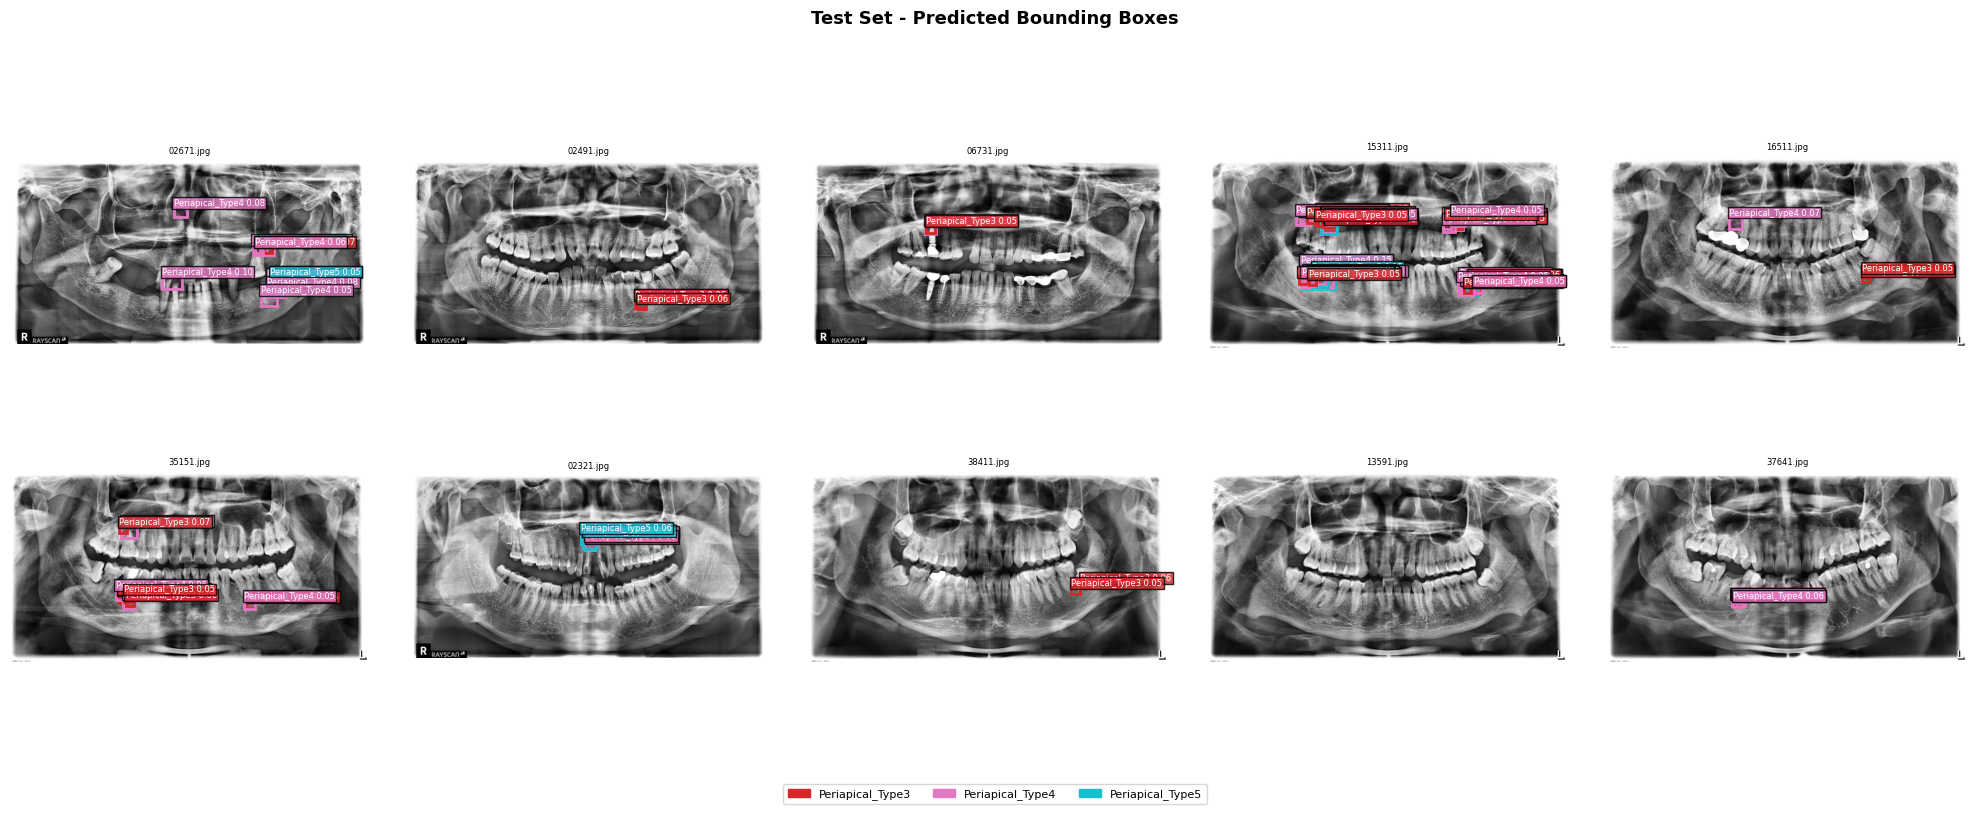

In [ ]:
def denormalize(tensor):
    """Reverse ImageNet normalization for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


@torch.no_grad()
def plot_predictions(model, dataset, class_names, conf=0.01, n=10,
                     title='Predictions'):
    """Display predicted bounding boxes on a random sample of test images."""
    model.eval()
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    cols    = 5
    rows    = math.ceil(len(indices) / cols)
    cmap    = plt.cm.get_cmap('tab10', len(class_names))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = np.array(axes).flatten()

    for ax, idx in zip(axes[:len(indices)], indices):
        img_t, _ = dataset[idx]
        img_np   = denormalize(img_t).permute(1, 2, 0).numpy()

        out    = model([img_t.to(DEVICE)])[0]
        boxes  = out['boxes'].cpu().numpy()
        scores = out['scores'].cpu().numpy()
        labels = out['labels'].cpu().numpy()

        ax.imshow(img_np)
        ax.set_title(dataset.samples[idx][0].name, fontsize=6)
        ax.axis('off')

        for box, cls_id, score in zip(boxes, labels, scores):
            if score < conf:
                continue
            color = cmap(cls_id)
            x1, y1, x2, y2 = box
            rect = mpatches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor=color, facecolor=(*color[:3], 0.15)
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 4, f'{class_names[cls_id]} {score:.2f}',
                    color='white', fontsize=6,
                    bbox=dict(facecolor=color, alpha=0.8, pad=1))

    for ax in axes[len(indices):]:
        ax.axis('off')

    legend = [mpatches.Patch(color=cmap(i), label=class_names[i])
              for i in range(1, len(class_names))]
    fig.legend(handles=legend, loc='lower center', ncol=len(class_names)-1,
               fontsize=8, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_predictions(best_model, test_dataset, CLASS_NAMES,
                 conf=CONF_THR, n=10, title='Test Set - Predicted Bounding Boxes')


/tmp/ipykernel_1380/1310558033.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap('tab10', len(class_names))
/tmp/ipykernel_1380/748942199.py:69: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(enhanced_rgb, mode='RGB')


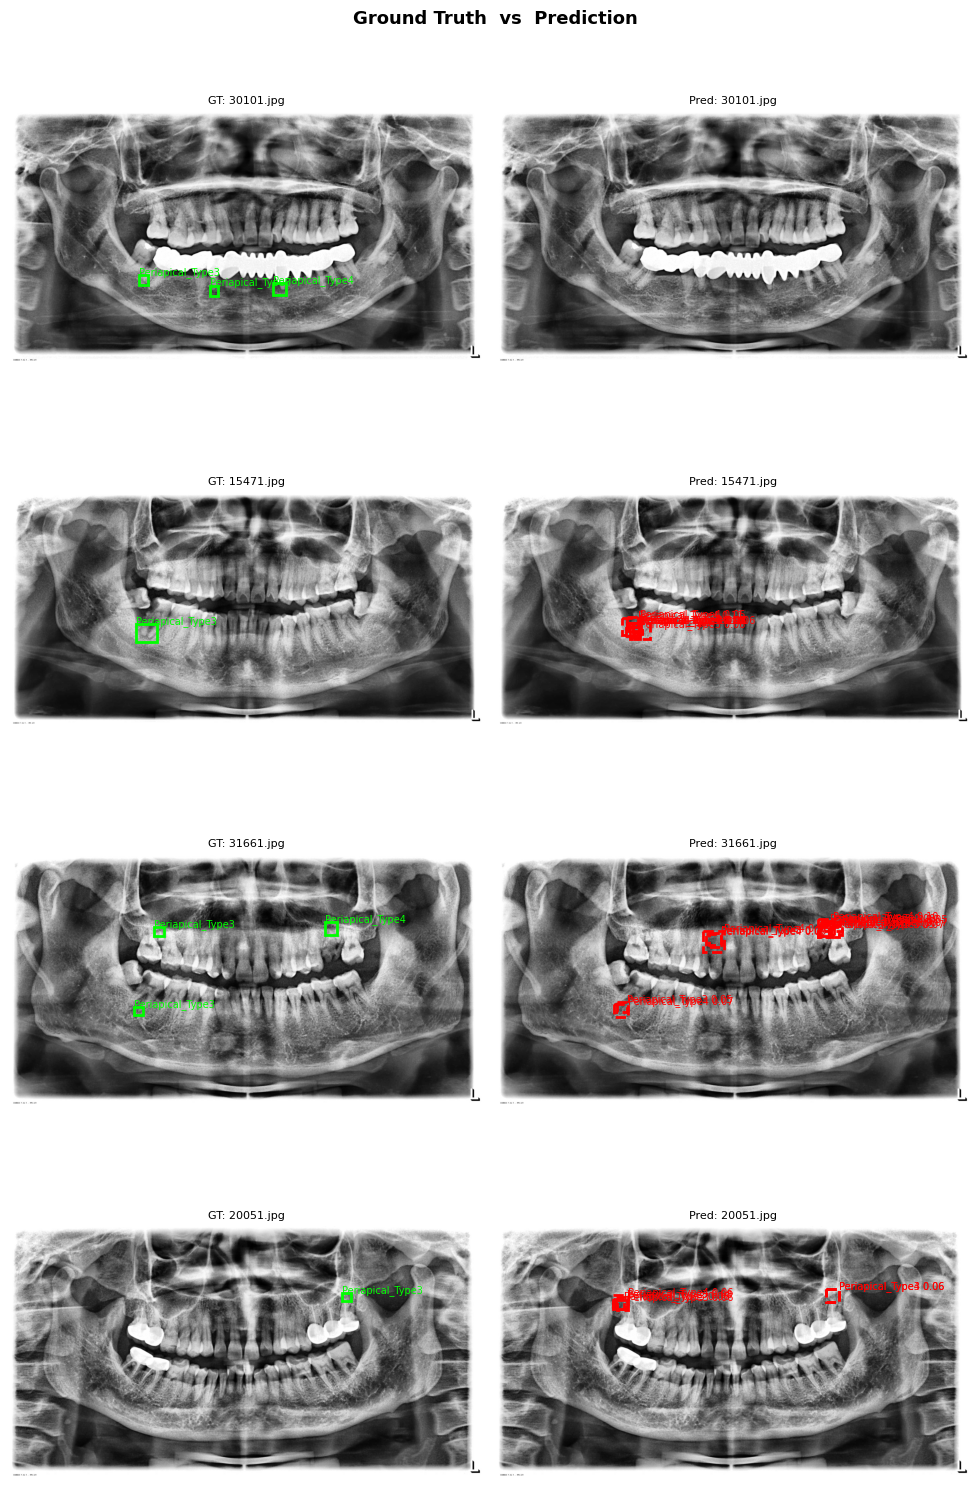

In [ ]:
# ── Ground-truth vs Prediction side-by-side ───────────────────────────────────
@torch.no_grad()
def plot_gt_vs_pred(model, dataset, class_names, conf=0.01, n=4):
    """Display GT and predicted boxes side by side for qualitative comparison."""
    model.eval()
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    cmap    = plt.cm.get_cmap('tab10', len(class_names))
    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))

    for row, idx in enumerate(indices):
        img_t, tgt = dataset[idx]
        img_np     = denormalize(img_t).permute(1, 2, 0).numpy()

        # Ground truth column
        ax_gt = axes[row, 0]
        ax_gt.imshow(img_np)
        ax_gt.set_title(f'GT: {dataset.samples[idx][0].name}', fontsize=8)
        ax_gt.axis('off')
        for box, cls_id in zip(tgt['boxes'].numpy(), tgt['labels'].numpy()):
            x1, y1, x2, y2 = box
            rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                       linewidth=2, edgecolor='lime', facecolor='none')
            ax_gt.add_patch(rect)
            ax_gt.text(x1, y1-4, class_names[cls_id], color='lime', fontsize=7)

        # Prediction column
        ax_pr = axes[row, 1]
        ax_pr.imshow(img_np)
        ax_pr.set_title(f'Pred: {dataset.samples[idx][0].name}', fontsize=8)
        ax_pr.axis('off')
        out = model([img_t.to(DEVICE)])[0]
        for box, cls_id, score in zip(out['boxes'].cpu().numpy(),
                                       out['labels'].cpu().numpy(),
                                       out['scores'].cpu().numpy()):
            if score < conf:
                continue
            color = cmap(cls_id)
            x1, y1, x2, y2 = box
            rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                       linewidth=2, edgecolor='red',
                                       facecolor='none', linestyle='--')
            ax_pr.add_patch(rect)
            ax_pr.text(x2, y1-4, f'{class_names[cls_id]} {score:.2f}',
                       color='red', fontsize=7)

    plt.suptitle('Ground Truth  vs  Prediction', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_gt_vs_pred(best_model, test_dataset, CLASS_NAMES, conf=CONF_THR, n=4)


 ## 7. Error Analysis



 Three types of detection errors are identified and visualized:



 1. **False Positives (FP)**: Predicted boxes with no matching ground-truth box.

 2. **False Negatives (FN)**: Ground-truth boxes that were not detected.

 3. **Low-confidence True Positives**: Correct detections with confidence below 0.5,

    indicating the model is uncertain about lesions it correctly found.

In [ ]:
@torch.no_grad()
def collect_error_cases(model, dataset, class_names,
                         conf=0.01, iou_thr=0.5, max_cases=20):
    """Collect FP, FN, and low-confidence TP examples from the dataset."""
    model.eval()
    fp_cases, fn_cases, lc_cases = [], [], []

    for idx in range(min(200, len(dataset))):
        img_t, tgt = dataset[idx]
        img_path   = dataset.samples[idx][0]

        gt_boxes  = tgt['boxes'].numpy().tolist()
        gt_labels = tgt['labels'].numpy().tolist()

        out = model([img_t.to(DEVICE)])[0]
        pred_boxes  = out['boxes'].cpu().numpy().tolist()
        pred_scores = out['scores'].cpu().numpy().tolist()
        pred_labels = out['labels'].cpu().numpy().tolist()

        preds = [{'box': b, 'cls': c, 'conf': s}
                 for b, c, s in zip(pred_boxes, pred_labels, pred_scores)
                 if s >= conf]
        gts   = [{'box': b, 'cls': c}
                 for b, c in zip(gt_boxes, gt_labels)]

        matched_gt, matched_pred = set(), set()
        for pi, p in enumerate(preds):
            for gi, g in enumerate(gts):
                if gi in matched_gt or g['cls'] != p['cls']:
                    continue
                if box_iou_np(p['box'], g['box']) >= iou_thr:
                    matched_gt.add(gi)
                    matched_pred.add(pi)
                    if p['conf'] < 0.5 and len(lc_cases) < max_cases:
                        lc_cases.append((img_path, img_t, preds, gts))
                    break

        if any(pi not in matched_pred for pi in range(len(preds))):
            if len(fp_cases) < max_cases:
                fp_cases.append((img_path, img_t, preds, gts))
        if any(gi not in matched_gt for gi in range(len(gts))):
            if len(fn_cases) < max_cases:
                fn_cases.append((img_path, img_t, preds, gts))

    return fp_cases, fn_cases, lc_cases


print('Collecting error cases...')
fp_cases, fn_cases, lc_cases = collect_error_cases(
    best_model, test_dataset, CLASS_NAMES,
    conf=CONF_THR, iou_thr=IOU_THR, max_cases=20
)
print(f'  False Positives : {len(fp_cases)}')
print(f'  False Negatives : {len(fn_cases)}')
print(f'  Low-conf TPs    : {len(lc_cases)}')


/tmp/ipykernel_1380/748942199.py:69: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(enhanced_rgb, mode='RGB')


  False Positives : 20
  False Negatives : 20
  Low-conf TPs    : 20


/tmp/ipykernel_1380/3621222903.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap('tab10', len(class_names))


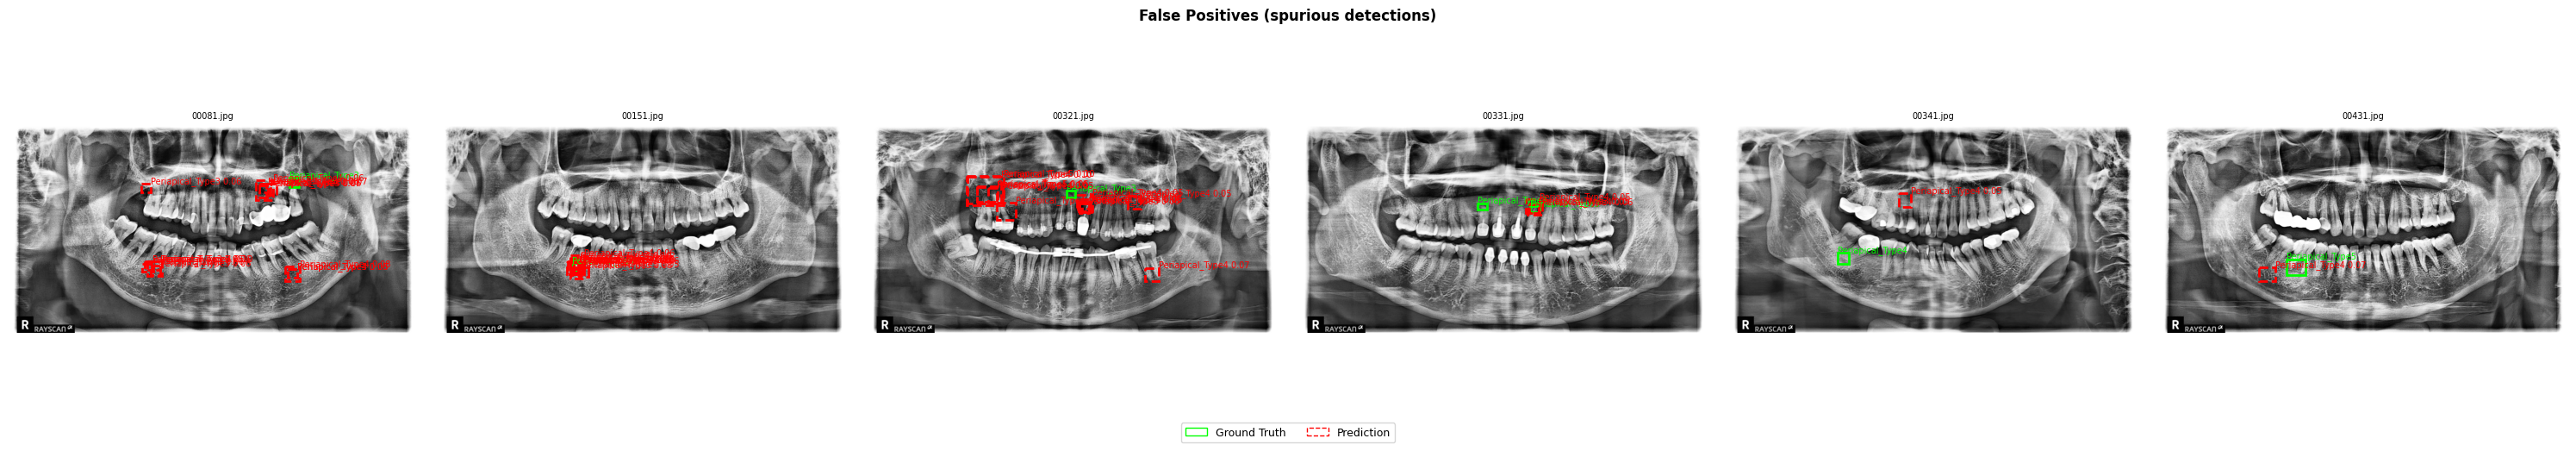

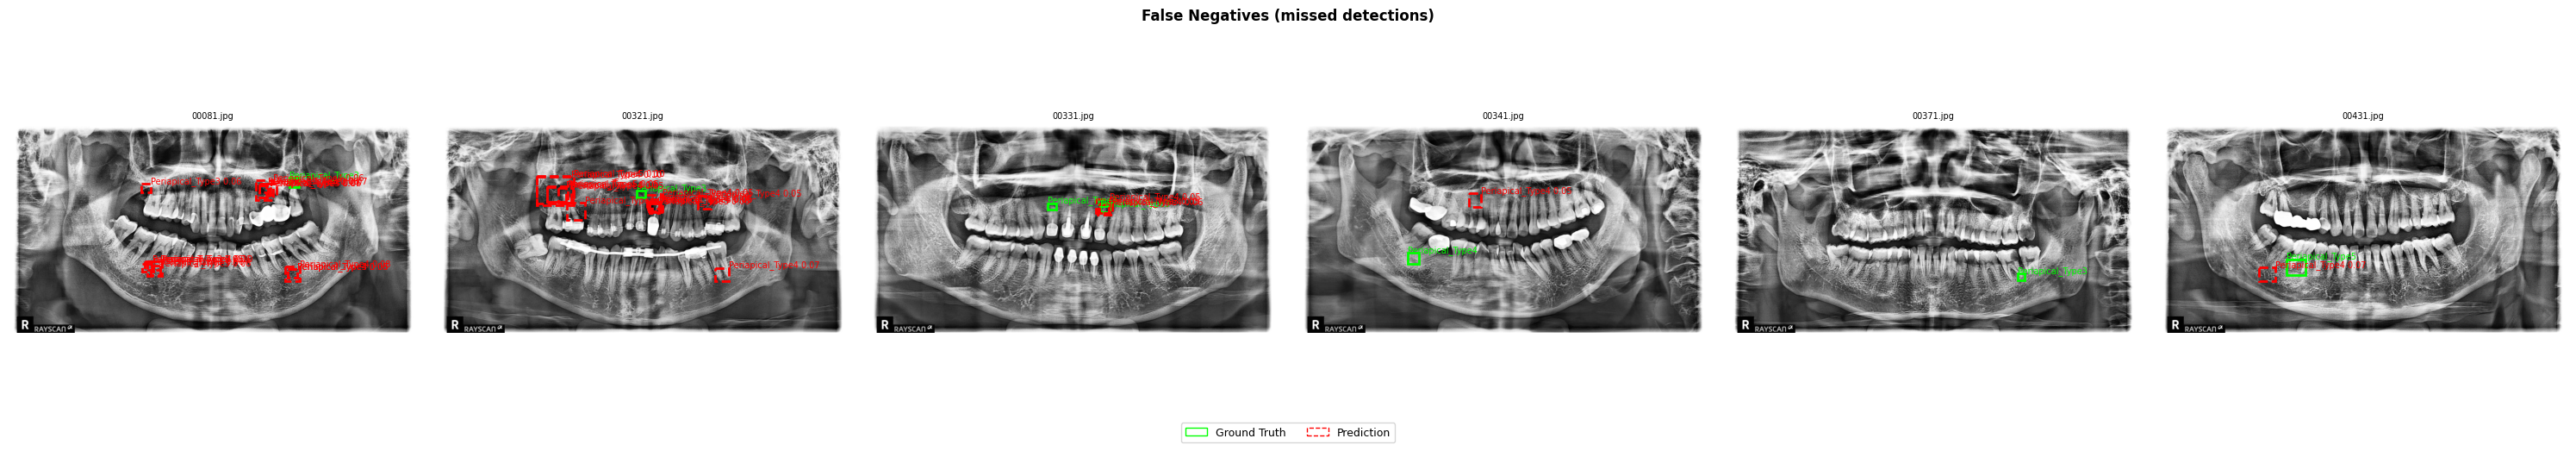

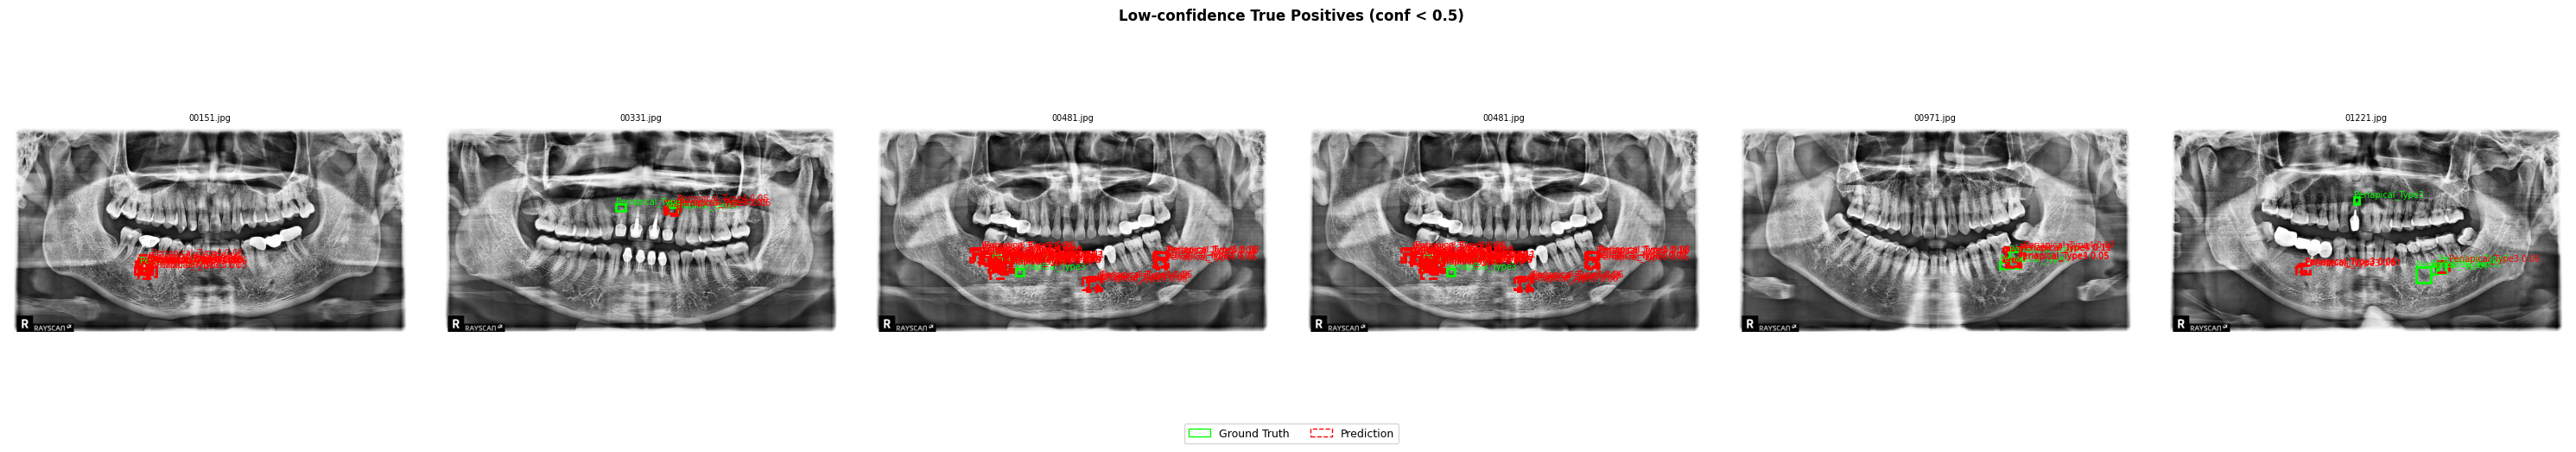

In [ ]:
def show_error_cases(cases, class_names, title='Error Cases', n=6):
    """Visualize a sample of error cases with GT and prediction overlays."""
    if not cases:
        print(f'No cases found for: {title}')
        return
    samples = cases[:n]
    cmap    = plt.cm.get_cmap('tab10', len(class_names))
    fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5))
    if len(samples) == 1:
        axes = [axes]

    for ax, (img_path, img_t, preds, gts) in zip(axes, samples):
        img_np = denormalize(img_t).permute(1, 2, 0).numpy()
        ax.imshow(img_np)
        ax.set_title(img_path.name, fontsize=7)
        ax.axis('off')

        for g in gts:
            x1, y1, x2, y2 = g['box']
            rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                       linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-4, class_names[g['cls']], color='lime', fontsize=7)

        for p in preds:
            x1, y1, x2, y2 = p['box']
            rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                       linewidth=2, edgecolor='red',
                                       facecolor='none', linestyle='--')
            ax.add_patch(rect)
            ax.text(x2, y1-4, f"{class_names[p['cls']]} {p['conf']:.2f}",
                    color='red', fontsize=7)

    legend = [
        mpatches.Patch(edgecolor='lime', facecolor='none', label='Ground Truth'),
        mpatches.Patch(edgecolor='red',  facecolor='none', label='Prediction', linestyle='--'),
    ]
    fig.legend(handles=legend, loc='lower center', ncol=2, fontsize=9,
               bbox_to_anchor=(0.5, -0.04))
    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


show_error_cases(fp_cases, CLASS_NAMES, title='False Positives (spurious detections)')
show_error_cases(fn_cases, CLASS_NAMES, title='False Negatives (missed detections)')
show_error_cases(lc_cases, CLASS_NAMES, title='Low-confidence True Positives (conf < 0.5)')


 ## 8. Confusion Matrix



 The confusion matrix shows how often each ground-truth class is detected as each

 predicted class, using IoU thresholding to match predictions to annotations.



 - **Diagonal cells**: Correct detections (True Positives).

 - **Off-diagonal cells**: Class confusion errors (e.g., Type3 predicted as Type4).

 - **Background row**: False Positives — predictions with no matching GT box.

 - **Background column**: False Negatives — GT boxes with no matching prediction.



 The background class is included for FP/FN counting but excluded from the main

 visualization to keep the matrix readable.

Building confusion matrix on test set...


  Confusion matrix:   0%|                               | 0/148 [00:00<?, ?it/s]

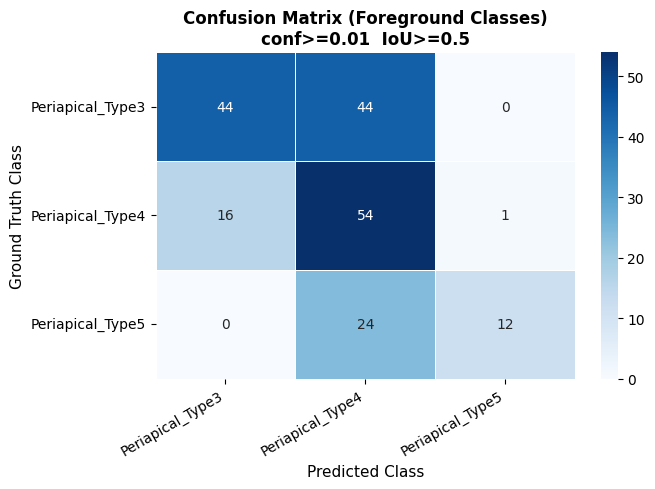


Full confusion matrix (including background):
                             __background  Periapical_T  Periapical_T  Periapical_T
             __background__             0          2284          2307           330
           Periapical_Type3           577            44            44             0
           Periapical_Type4           191            16            54             1
           Periapical_Type5            74             0            24            12


In [ ]:
@torch.no_grad()
def build_confusion_matrix(model, loader, class_names, conf_thr=0.01, iou_thr=0.5):
    """
    Build a confusion matrix for object detection by matching predictions to
    ground-truth boxes using IoU thresholding.

    Rows    : Ground-truth classes (including background for FN).
    Columns : Predicted classes (including background for FP).
    """
    model.eval()
    n = len(class_names)  # includes __background__
    cm = np.zeros((n, n), dtype=np.int32)

    for images, targets in tqdm(loader, desc='  Confusion matrix', leave=False, ncols=80):
        images  = [img.to(DEVICE) for img in images]
        outputs = model(images)

        for out, tgt in zip(outputs, targets):
            pred_boxes  = out['boxes'].cpu().numpy()
            pred_scores = out['scores'].cpu().numpy()
            pred_labels = out['labels'].cpu().numpy()
            gt_boxes    = tgt['boxes'].numpy()
            gt_labels   = tgt['labels'].numpy()

            keep        = pred_scores >= conf_thr
            pred_boxes  = pred_boxes[keep]
            pred_labels = pred_labels[keep]

            matched_gt   = set()
            matched_pred = set()

            # Match predictions to ground truth
            for pi in range(len(pred_boxes)):
                best_iou, best_gi = 0.0, -1
                for gi in range(len(gt_boxes)):
                    if gi in matched_gt:
                        continue
                    iou = box_iou_np(pred_boxes[pi], gt_boxes[gi])
                    if iou > best_iou:
                        best_iou, best_gi = iou, gi

                if best_iou >= iou_thr and best_gi >= 0:
                    # True Positive (may be correct class or class confusion)
                    gt_cls   = gt_labels[best_gi]
                    pred_cls = pred_labels[pi]
                    cm[gt_cls, pred_cls] += 1
                    matched_gt.add(best_gi)
                    matched_pred.add(pi)
                else:
                    # False Positive: no GT match -> pred maps to background GT row
                    cm[0, pred_labels[pi]] += 1

            # False Negatives: unmatched GT boxes -> GT class maps to background pred
            for gi in range(len(gt_boxes)):
                if gi not in matched_gt:
                    cm[gt_labels[gi], 0] += 1

    return cm


print('Building confusion matrix on test set...')
cm = build_confusion_matrix(best_model, test_loader, CLASS_NAMES,
                             conf_thr=CONF_THR, iou_thr=IOU_THR)

# ── Visualize confusion matrix (foreground classes only) ──────────────────────
# Exclude background class (index 0) from visualization for clarity
fg_names = CLASS_NAMES[1:]   # ['Periapical_Type3', 'Periapical_Type4', 'Periapical_Type5']
cm_fg    = cm[1:, 1:]        # foreground x foreground sub-matrix

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_fg,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=fg_names,
    yticklabels=fg_names,
    linewidths=0.5,
    ax=ax,
)
ax.set_xlabel('Predicted Class', fontsize=11)
ax.set_ylabel('Ground Truth Class', fontsize=11)
ax.set_title('Confusion Matrix (Foreground Classes)\n'
             f'conf>={CONF_THR}  IoU>={IOU_THR}', fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(str(RUN_DIR / 'confusion_matrix.png'), dpi=120, bbox_inches='tight')
plt.show()

# Print numeric summary including FP/FN rows/cols
print('\nFull confusion matrix (including background):')
print(f'  {"":>25}', end='')
for cn in CLASS_NAMES:
    print(f'  {cn[:12]:>12}', end='')
print()
for r, row_name in enumerate(CLASS_NAMES):
    print(f'  {row_name[:25]:>25}', end='')
    for val in cm[r]:
        print(f'  {val:>12}', end='')
    print()
